In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import r2_score, mean_squared_error
#chinmayee making changes

In [11]:
df = pd.read_csv(r"C:\Users\bhava\paddy-yield-prediction\paddydataset.csv")

df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

(2789, 45)

In [12]:
df.drop_duplicates(inplace=True)

Identify Categorical Columns


In [13]:
df.select_dtypes(include='object').columns

Index(['Agriblock', 'Variety', 'Soil Types', 'Nursery',
       'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
       'Wind Direction_D61_D90', 'Wind Direction_D91_D120'],
      dtype='object')

Encode them

In [14]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [15]:
target_column = "Paddy yield(in Kg)"
X = df.drop("Paddy yield(in Kg)", axis=1)
y = df["Paddy yield(in Kg)"]

scaling

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


linear Regression


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Random forest


In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Support Vector Machine

In [ ]:
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

Evaluation Function

In [ ]:
def evaluate_model(actual, predicted, model_label):
    r2 = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"\n🔹 {model_label}")
    print("R2 Score:", r2)
    print("RMSE:", rmse)

EVALUATE ALL MODELS

In [ ]:
evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, svm_predictions, "SVM")



🔹 Linear Regression
R2 Score: 0.9876950807445436
RMSE: 1026.3642617402368

🔹 Random Forest
R2 Score: 0.9890274266094701
RMSE: 969.2066480976354

🔹 SVM
R2 Score: -0.008798731447644315
RMSE: 9293.18111059294


FEATURE IMPORTANCE (Random Forest)

In [23]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feat_df.head(10))


Top 10 Important Features:
                      Feature  Importance
4             Seedrate(in Kg)    0.106734
9                  DAP_20days    0.101804
13      Micronutrients_70Days    0.096660
7        Nursery area (Cents)    0.090800
8   LP_nurseryarea(in Tonnes)    0.089754
10        Weed28D_thiobencarb    0.081981
43          Trash(in bundles)    0.078166
12             Potassh_50Days    0.074855
0                   Hectares     0.073872
11                Urea_40Days    0.073667


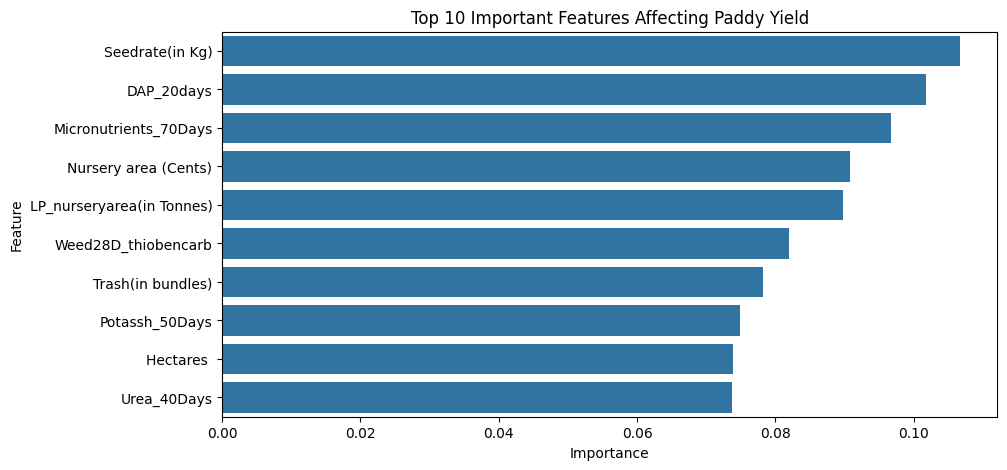

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Important Features Affecting Paddy Yield")
plt.show()